In [104]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import ast
import ipywidgets as widgets
from IPython.display import display, clear_output

In [143]:
directors = pd.read_csv('director_list.csv')

#print(directors.head())

results = []

for i in range(len(directors)):

    df = pd.read_csv(f"director_{i}.csv")

    # sort movies by year
    df = df.sort_values('release_year')

    # latest movie
    latest = df.iloc[-1]

    # historical movies
    historical = df.iloc[:-1]

    hist_avg_score = historical["avg_score"].mean()
    hist_avg_roi  = (historical['revenue'] / historical['budget']).mean()
    hist_avg_revenue = historical['revenue'].mean()
    hist_votes = historical['imdb_vote_count'].sum()

    new_score = latest['avg_score']
    new_roi = latest['revenue']/latest['budget']
    new_revenue = latest['revenue']
    new_votes = latest['imdb_vote_count']

    results.append({
        'director' : directors['name'][i],
        'hist_avg_score' : hist_avg_score,
        'hist_avg_roi' : hist_avg_roi,
        'hist_avg_revenue' : hist_avg_revenue,
        'hist_total_votes' : hist_votes,
        'new_score' : new_score,
        'new_roi' : new_roi,
        'new_revenue' : new_revenue,
        'new_votes' : new_votes 
    })

analysis_df = pd.DataFrame(results)
print(analysis_df)
corr = analysis_df.corr(numeric_only=True)
#print(corr)

                director  hist_avg_score  hist_avg_roi  hist_avg_revenue  \
0      Christopher Nolan        8.001818      5.271536      4.728488e+08   
1       Steven Spielberg        7.402424      9.755039      3.214671e+08   
2        Martin Scorsese        7.959524      3.451985      1.038611e+08   
3          Taika Waititi        7.604000      5.436702      3.457797e+08   
4          James Cameron        7.848750      7.874853      1.098666e+09   
5             Chloé Zhao        6.920000      4.950983      2.207616e+08   
6           Ryan Coogler        7.957500      8.608372      6.000571e+08   
7         Hayao Miyazaki        8.364545      6.379765      1.018500e+08   
8        S. S. Rajamouli        8.180000      6.332950      1.857238e+08   
9          David Fincher        7.571818      3.531398      1.948729e+08   
10      Denis Villeneuve        8.098333      2.505180      1.812015e+08   
11          Wes Anderson        7.696364      2.273756      5.557100e+07   
12    Guille

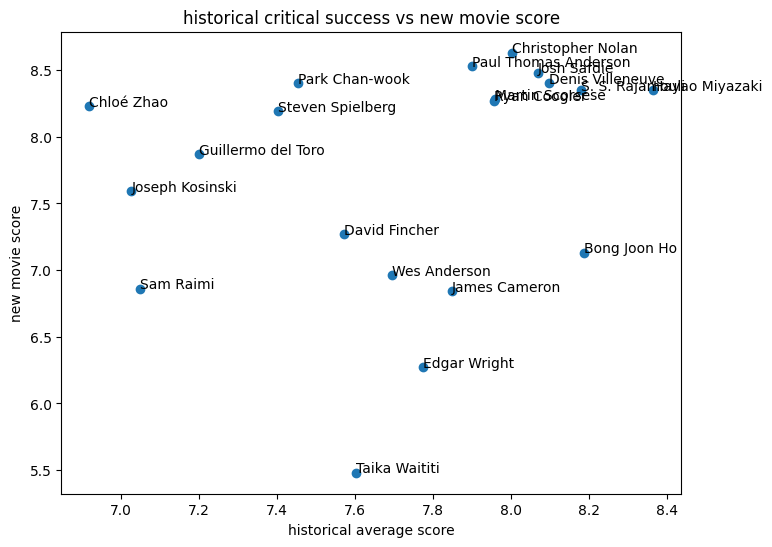

In [107]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_avg_score'], analysis_df['new_score'])

for i, director in enumerate(analysis_df['director']):
    plt.text(
        analysis_df['hist_avg_score'][i],
        analysis_df['new_score'][i],
        director
    )

plt.xlabel('historical average score')
plt.ylabel('new movie score')
plt.title('historical critical success vs new movie score')

plt.show()

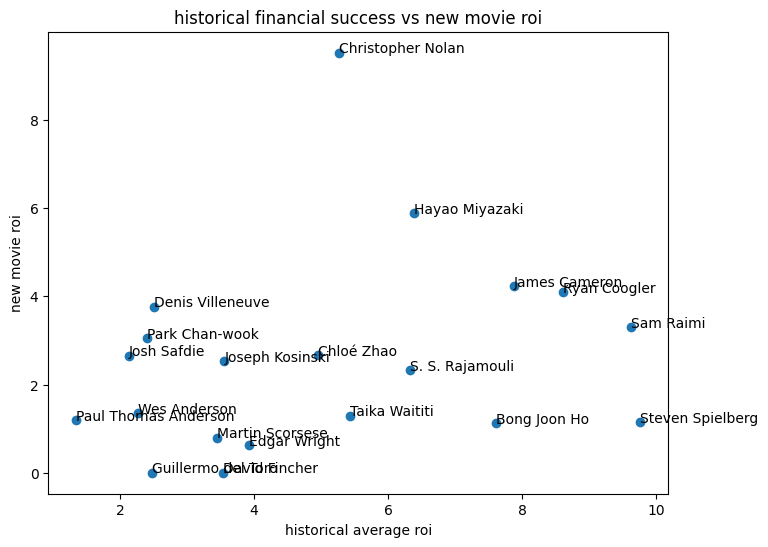

In [128]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_avg_roi'], analysis_df['new_roi'])

for i, director in enumerate(analysis_df['director']):
    plt.text(
        analysis_df['hist_avg_roi'][i],
        analysis_df['new_roi'][i],
        director
    )

plt.xlabel('historical average roi')
plt.ylabel('new movie roi')
plt.title('historical financial success vs new movie roi')

plt.show()

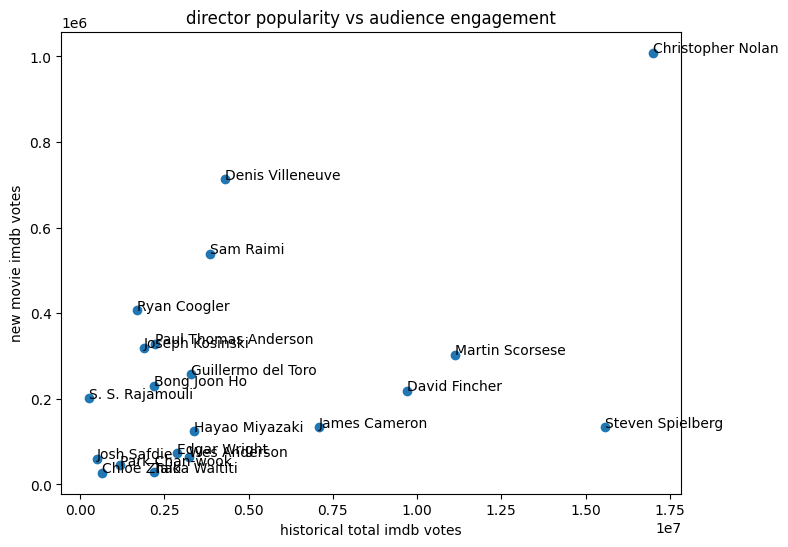

In [129]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_total_votes'], analysis_df['new_votes'])
for i, director in enumerate(analysis_df['director']):
    plt.text(
        analysis_df['hist_total_votes'][i],
        analysis_df['new_votes'][i],
        director
    )


plt.xlabel('historical total imdb votes')
plt.ylabel('new movie imdb votes')
plt.title('director popularity vs audience engagement')

plt.show()

In [110]:
def load_director_score_matrix(director_ids):

    dfs = []

    for i in director_ids:

        df = pd.read_csv(f'director_{i}.csv')

        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')

        df = df.dropna(subset=['release_year', 'avg_score'])

        df['director_id'] = analysis_df['director'][i]

        dfs.append(df)
    combined = pd.concat(dfs)

    matrix = combined.pivot_table(
        index = 'director_id',
        columns = 'release_year',
        values = 'avg_score',
        aggfunc = 'mean'
    )
    return matrix

In [111]:
def plot_director_heatmap(director_ids):
    matrix = load_director_score_matrix(director_ids)
    
    plt.figure(figsize=(14,6))

    plt.imshow(matrix, aspect='auto', cmap='RdYlGn')

    plt.colorbar(label='average score')

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.tight_layout()
    plt.show()

In [112]:
def load_and_clean_director_data(director_ids):

    data = {}

    for i in director_ids:
        df = pd.read_csv(f"director_{i}.csv")

        df = df.copy()
        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')

        df = df.dropna(subset=['release_year','avg_score'])
        df = df.sort_values('release_year')

        data[i] = df

    return data

In [126]:
def plot_director_careers(director_ids):

    data = load_and_clean_director_data(director_ids)

    plt.figure(figsize=(12,6))

    for director_id, df in data.items():
        
        plt.plot(
            df['release_year'],
            df['avg_score'],
            marker='o',
            label=analysis_df['director'][director_id]
        )
    
    plt.xlabel('release year')
    plt.ylabel('average score')

    plt.title('director career critical performance over time')

    plt.legend()

    plt.grid(True, alpha=0.3)
    
    plt.show()



In [127]:
output = widgets.Output()
director_ids = list(range(0,len(analysis_df)-1))

checkboxes = [widgets.Checkbox(value=True, description=analysis_df['director'][i]) for i in director_ids]

def update_heatmap(change=None):

    selected = [i for i, cb in enumerate(checkboxes) if cb.value]

    with output:
        clear_output(wait=True)

        if selected:
            plot_director_heatmap(selected)
        else:
            print('select at least one director')

def update_plot(change=None):
    
    selected = [i for i, cb in enumerate(checkboxes) if cb.value]

    with output:
        clear_output(wait=True)

        if selected:
            plot_director_careers(selected)

for cb in checkboxes:
    #cb.observe(update_heatmap, names = 'value')
    cb.observe(update_plot, 'value')

display(widgets.VBox(checkboxes))
display(output)

update_heatmap()

update_plot()

Output()

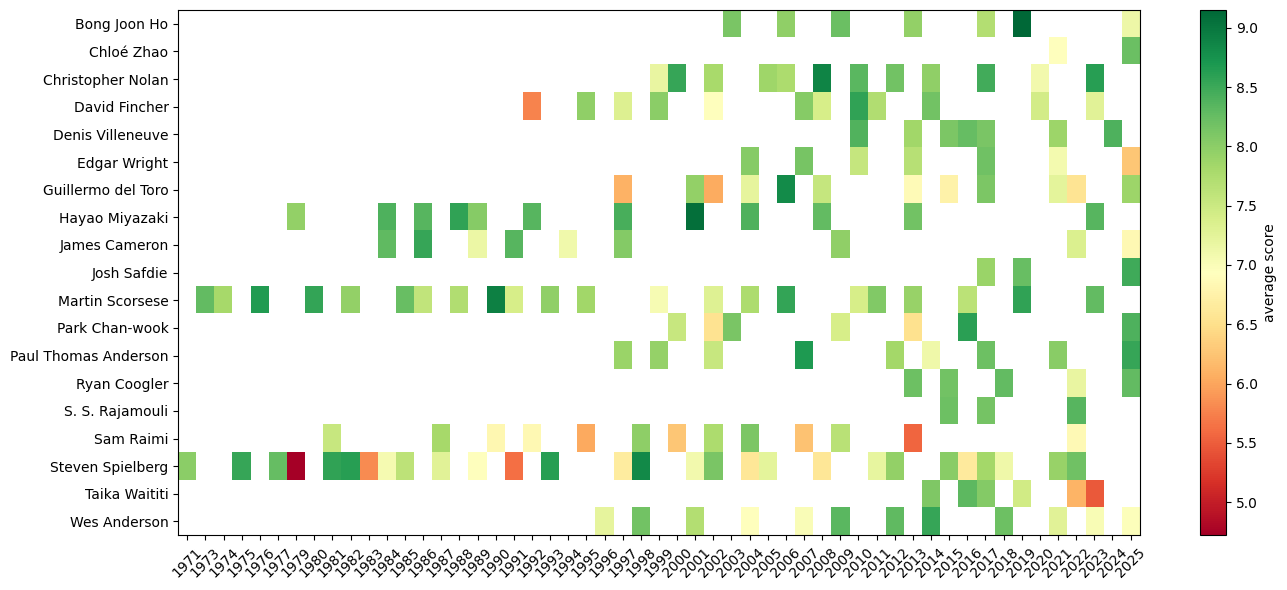

In [115]:
matrix = load_director_score_matrix(director_ids)
    
plt.figure(figsize=(14,6))

plt.imshow(matrix, aspect='auto', cmap='RdYlGn')

plt.colorbar(label='average score')

plt.yticks(
    range(len(matrix.index)),
    matrix.index
)

plt.xticks(
    range(len(matrix.columns)),
    matrix.columns,
    rotation=45
)

plt.tight_layout()
plt.show()

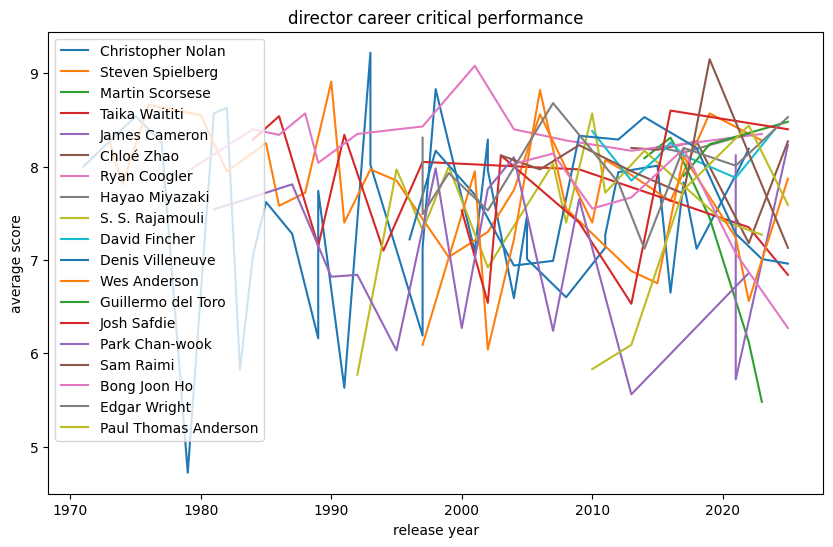

In [117]:
plt.figure(figsize=(10,6))

for i in range(1, len(analysis_df)):
    df = pd.read_csv(f'director_{i}.csv')
    df = df.sort_values('release_year')

    plt.plot(df['release_year'], df['avg_score'], label=directors['name'][i-1])

plt.xlabel('release year')
plt.ylabel('average score')
plt.title('director career critical performance')

plt.legend()
plt.show()



In [136]:
director_colors = {
    0: "tab:black",
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green",
    4: "tab:red",
    5: "tab:purple",
    6: "tab:brown",
    7: "tab:pink",
    8: "tab:gray",
    9: "tab:olive",
    10: "tab:cyan"
}

def load_budget_revenue_data(director_ids):
    
    data = []

    for i in director_ids:
        df = pd.read_csv(f'director_{i}.csv')

        df = df.copy()

        df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

        df = df.dropna(subset=['budget', 'revenue'])

        df['roi'] = df['revenue'] / df['budget']
        df['director_id'] = i
        df['color'] = director_colors[i]
        df['name'] = analysis_df['director'][i]

        data.append(df)
    
    if len(data)==0:
        return pd.DataFrame()
    
    return pd.concat(data, ignore_index=True)


In [139]:
def plot_budget_vs_revenue(director_ids):

    df = load_budget_revenue_data(director_ids)

    if df.empty:
        print("no data to display")
        return
    
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10,7))

    ax.scatter(
        df['budget'],
        
    )
    for id in director_ids:
        




        scatter = plt.scatter(
            df['budget'],
            df['revenue'],
            c = df['color'],
            alpha=0.75,
            s = 70
        )
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel('budget (log scale)')
    plt.ylabel('revenue (log scale)')
    plt.title('budget vs revenue (roi colored)')

    legend_elements = [
        Line2D(
            [0], [0],
            marker = 'o',
            color = 'w',
            label = analysis_df['director'][i],
            markerfacecolor=director_colors[i],
            markersize=10
        )
        for i in director_ids
    ]

    plt.colorbar(scatter, label = "roi")

    plt.legend(handles=legend_elements)

    plt.grid(True, alpha=0.3)

    plt.show()

Output()

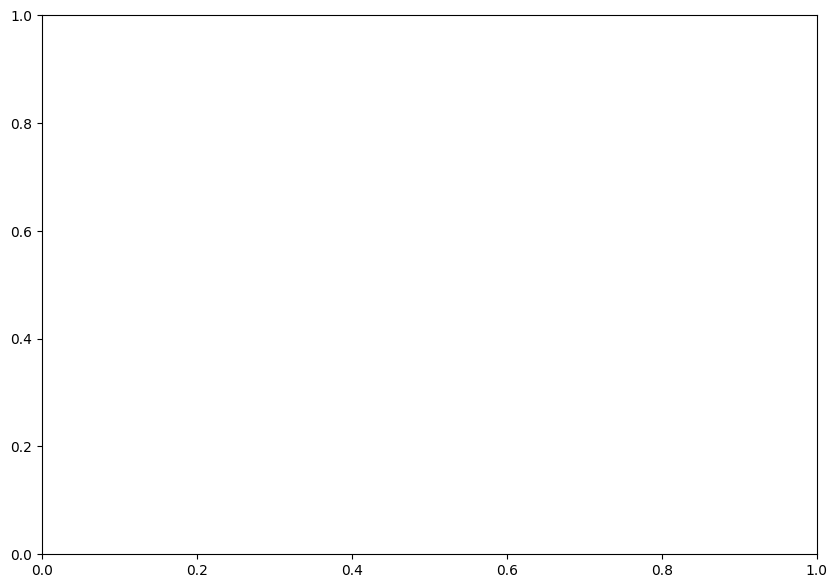

In [140]:
director_ids = list(range(1,11))

checkboxes = [
    widgets.Checkbox(value=True, description=f"Director {i}")
    for i in director_ids
    ]
output = widgets.Output()

def update_scatter(change = None):
    
    selected = [i for i, cb in enumerate(checkboxes) if cb.value]
    
    with output:
        clear_output(wait=True)

        if selected:
            plot_budget_vs_revenue(selected)
        else:
            print('select at least one director.')

for cb in checkboxes:
    cb.observe(update_scatter, "value")

display(widgets.VBox(checkboxes))
display(output)

update_scatter()

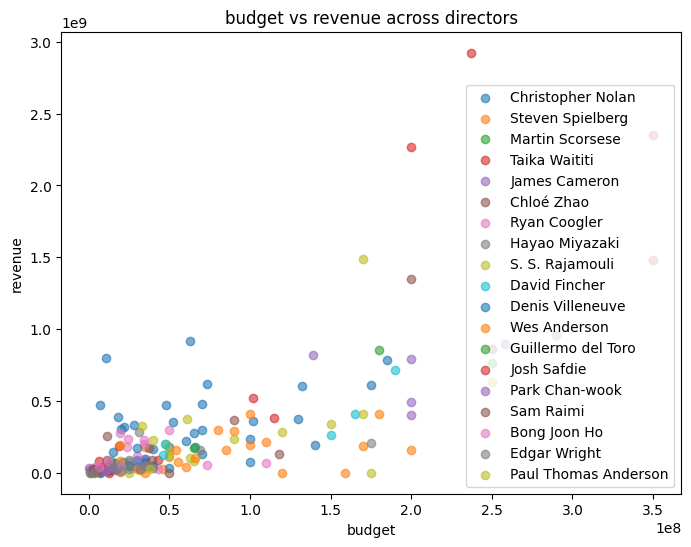

In [141]:
plt.figure(figsize=(8,6))

for i in range(1,len(analysis_df)):
    df = pd.read_csv(f'director_{i}.csv')

    plt.scatter(df['budget'], df['revenue'], alpha=0.6, label=directors['name'][i-1])

plt.xlabel('budget')
plt.ylabel('revenue')
plt.title('budget vs revenue across directors')

plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

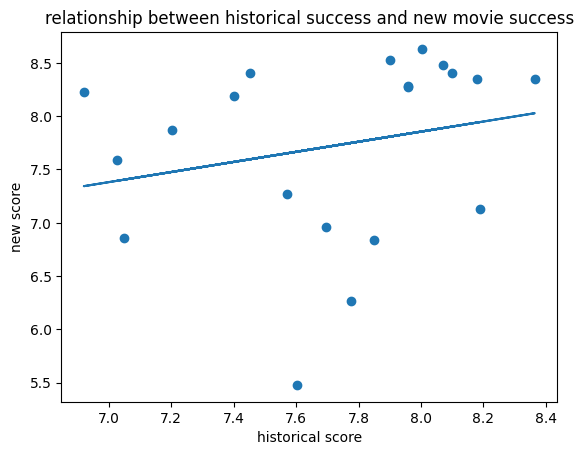

In [144]:
x = analysis_df['hist_avg_score']
y= analysis_df['new_score']

m, b = np.polyfit(x,y,1)

plt.scatter(x,y)
plt.plot(x, m*x + b)

plt.xlabel('historical score')
plt.ylabel('new score')
plt.title('relationship between historical success and new movie success')

plt.show